| Pieza (Semana 6) | Fórmula | Cambio en este lab |
|---|---|---|
| `make_positional_encoding` | $PE(t,2i)=\sin(t/10000^{2i/d})$, $PE(t,2i+1)=\cos(t/10000^{2i/d})$ | igual, con `max_len = block_size = 128` |
| `layer_norm` | $\gamma \odot \frac{x-\mu}{\sqrt{\sigma^2+\epsilon}}+\beta$ | igual |
| `masked_self_attention` | $\text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}} + M\right)V$, con $M_{ij}=-\infty$ si $j>i$ | ahora procesa **batches** `(B, T, d_model)` |
| FFN | $\text{ReLU}(xW_1+b_1)W_2+b_2$ | misma fórmula, con $d_{ff}=4\,d_{model}=512$ (en S6 era $2\,d_{model}$) |
| Bloque decoder | Add & LayerNorm | se apilan **`n_layers = 3`** bloques (orden Pre-LN, ver Task 1.2) |
| LM head | $\text{logits}=xW_{lm}+b_{lm}$ | vocabulario de **65 caracteres** en lugar de palabras |
| `generate` | $\text{softmax}(z/\tau)$ + `multinomial` | se separa en 3 estrategias: greedy, top-k y top-p |

## Bloque 0: imports y semillas

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math, os, random, time, urllib.request
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

SEED = 1337
torch.manual_seed(SEED); random.seed(SEED); np.random.seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch {torch.__version__} | device: {device}')

PyTorch 2.14.0+cpu | device: cpu


# Task 1

## Task 1.1: dataset, vocabulario y batches

In [ ]:
# Descarga del corpus tiny_shakespeare (~1.1M caracteres)
URL = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
DATA_PATH = 'tiny_shakespeare.txt'
if not os.path.exists(DATA_PATH):
    urllib.request.urlretrieve(URL, DATA_PATH)

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    text = f.read()

print(f'Caracteres totales: {len(text):,}')
print(text[:250])

Caracteres totales: 1,115,394
----------------------------------------
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.



In [3]:
# Vocabulario de caracteres unicos (ordenado para que los indices sean reproducibles)
chars = sorted(set(text))
vocab_size = len(chars)
assert vocab_size == 65, f'El vocabulario debe tener 65 caracteres, tiene {vocab_size}'

# Mappings bidireccionales caracter <-> indice
stoi = {ch: i for i, ch in enumerate(chars)}   # char  -> int
itos = {i: ch for ch, i in stoi.items()}       # int   -> char

encode = lambda s: [stoi[c] for c in s]          # str       -> list[int]
decode = lambda l: ''.join(itos[int(i)] for i in l)  # list[int] -> str

print(f'vocab_size = {vocab_size}')
print('Vocabulario:', repr(''.join(chars)))
print('encode("ROMEO:") =', encode('ROMEO:'))
print('decode(encode("ROMEO:")) =', decode(encode('ROMEO:')))

vocab_size = 65
Vocabulario: "\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
encode("ROMEO:") = [30, 27, 25, 17, 27, 10]
decode(encode("ROMEO:")) = ROMEO:


In [4]:
# Codificar todo el texto como secuencia de indices
data = torch.tensor(encode(text), dtype=torch.long)

# Split 90/10 respetando el orden temporal (sin shuffle): el bloque final del texto
# queda para validacion, asi el modelo nunca ve durante el entrenamiento el texto que se evalua.
n_train = int(0.9 * len(data))
train_data = data[:n_train]
val_data   = data[n_train:]
print(f'data: {data.shape} | train: {len(train_data):,} tokens | val: {len(val_data):,} tokens')

data: torch.Size([1115394]) | train: 1,003,854 tokens | val: 111,540 tokens


In [5]:
# Hiperparametros minimos del enunciado
block_size = 128   # T: largo de contexto
d_model    = 128
n_heads    = 4
n_layers   = 3
batch_size = 64
lr         = 3e-4
epochs     = 20    # el enunciado pide minimo 10. Con 20 se obtiene val ppl ~6.0 (con 10 da ~7.2)

d_k  = d_model // n_heads   # 32 por cabeza
d_ff = 4 * d_model          # 512, como en Vaswani et al.

def get_batch(split, batch_size=batch_size, block_size=block_size):
    '''
    Genera un batch de secuencias de largo fijo.
      x[b] = data[i : i+T]        (entrada)
      y[b] = data[i+1 : i+T+1]    (objetivo = entrada desplazada un paso al futuro)
    Asi en cada posicion t el modelo aprende P(x_{t+1} | x_1..x_t).
    '''
    d = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - block_size - 1, (batch_size,))
    x = torch.stack([d[i:i + block_size] for i in ix])
    y = torch.stack([d[i + 1:i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

xb, yb = get_batch('train')
print(f'x: {tuple(xb.shape)}  y: {tuple(yb.shape)}')
print('x[0][:30] =', repr(decode(xb[0][:30])))
print('y[0][:30] =', repr(decode(yb[0][:30])))
assert torch.equal(xb[:, 1:], yb[:, :-1]), 'y debe ser x desplazado un paso'

x: (64, 128)  y: (64, 128)
x[0][:30] = ' if die, be brief,\nThat our sw'
y[0][:30] = 'if die, be brief,\nThat our swi'


## Task 1.2

Se reutilizan `make_positional_encoding`, `layer_norm` y la atención con máscara causal de la Semana 6. Cambian tres cosas:

1. **Batches:** los tensores pasan de `(T, d)` a `(B, T, d)`.
2. **Profundidad:** se apilan `n_layers = 3` bloques decoder.
3. **Orden de la normalización (Pre-LN):** en la Semana 6 el bloque era *Post-LN*, $x \leftarrow \text{LN}(x + \text{Sublayer}(x))$. Con 3 bloques se usa *Pre-LN* (GPT-2): $x \leftarrow x + \text{Sublayer}(\text{LN}(x))$, más una LN final antes de la cabeza LM. Así el camino residual queda limpio y el gradiente fluye mejor. En una prueba con la configuración mínima (10 épocas), Post-LN se quedó en perplejidad ≈ 8.1 y Pre-LN llegó a ≈ 7.2.

In [ ]:
# Piezas reutilizadas de la Semana 6
def make_positional_encoding(max_len, d_model):
    '''PE(t,2i) = sin(t / 10000^(2i/d_model)),  PE(t,2i+1) = cos(t / 10000^(2i/d_model))'''
    pe = torch.zeros(max_len, d_model)
    pos = torch.arange(max_len).unsqueeze(1).float()
    div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div)
    return pe

def layer_norm(x, gamma, beta, eps=1e-5):
    '''LN(x) = gamma * (x - mu) / sqrt(var + eps) + beta, sobre la ultima dimension'''
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, unbiased=False, keepdim=True)
    return gamma * (x - mean) / torch.sqrt(var + eps) + beta

# Mascara causal: True (triangulo superior) = posicion futura, se enmascara con -inf
CAUSAL_MASK = torch.triu(torch.ones(block_size, block_size), diagonal=1).bool().to(device)
PE = make_positional_encoding(block_size, d_model).to(device)
print(CAUSAL_MASK[:5, :5].int())

tensor([[0, 1, 1, 1, 1],
        [0, 0, 1, 1, 1],
        [0, 0, 0, 1, 1],
        [0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0]], dtype=torch.int32)


In [7]:
class DecoderBlock(nn.Module):
    '''Un bloque decoder: masked multi-head self-attention + FFN, ambos con residual (Pre-LN).'''
    def __init__(self, d_model, d_ff, n_heads):
        super().__init__()
        self.n_heads, self.d_k, self.d_model = n_heads, d_model // n_heads, d_model
        std = 0.02  # init pequena estilo GPT-2 (en S6 era 0.1 con d_model=32)
        # Proyecciones de atencion WQ, WK, WV, WO (d_model x d_model)
        self.WQ = nn.Parameter(torch.randn(d_model, d_model) * std)
        self.WK = nn.Parameter(torch.randn(d_model, d_model) * std)
        self.WV = nn.Parameter(torch.randn(d_model, d_model) * std)
        self.WO = nn.Parameter(torch.randn(d_model, d_model) * std)
        # LayerNorm 1 y 2
        self.gamma1 = nn.Parameter(torch.ones(d_model));  self.beta1 = nn.Parameter(torch.zeros(d_model))
        self.gamma2 = nn.Parameter(torch.ones(d_model));  self.beta2 = nn.Parameter(torch.zeros(d_model))
        # FFN
        self.W1 = nn.Parameter(torch.randn(d_model, d_ff) * std); self.bias1 = nn.Parameter(torch.zeros(d_ff))
        self.W2 = nn.Parameter(torch.randn(d_ff, d_model) * std); self.bias2 = nn.Parameter(torch.zeros(d_model))

    def masked_self_attention(self, x):
        '''
        x: (B, T, d_model) -> out: (B, T, d_model), attn_w: (B, n_heads, T, T)
        Attention(Q,K,V) = softmax(Q K^T / sqrt(d_k) + M) V,   M_ij = -inf si j > i
        '''
        B, T, _ = x.shape
        # 1. Q = xWQ, K = xWK, V = xWV  -> reshape a (B, n_heads, T, d_k)
        Q = (x @ self.WQ).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        K = (x @ self.WK).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        V = (x @ self.WV).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        # 2. scores escalados por sqrt(d_k) para que el softmax no se sature
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)        # (B, h, T, T)
        # 3. mascara causal: cada token solo atiende a posiciones <= t
        scores = scores.masked_fill(CAUSAL_MASK[:T, :T], float('-inf'))
        attn_w = F.softmax(scores, dim=-1)
        # 4. concatenar cabezas y proyectar con WO
        out = (attn_w @ V).transpose(1, 2).contiguous().view(B, T, self.d_model)
        return out @ self.WO, attn_w

    def feed_forward(self, x):
        '''FFN(x) = ReLU(x W1 + b1) W2 + b2  (por posicion)'''
        return F.relu(x @ self.W1 + self.bias1) @ self.W2 + self.bias2

    def forward(self, x):
        # Pre-LN: x = x + Sublayer(LN(x))
        att_out, _ = self.masked_self_attention(layer_norm(x, self.gamma1, self.beta1))
        x = x + att_out
        x = x + self.feed_forward(layer_norm(x, self.gamma2, self.beta2))
        return x


class MiniGPT(nn.Module):
    '''Transformer decoder-only a nivel de caracter (Mini-GPT de la Semana 6 con n_layers bloques).'''
    def __init__(self, V, d_model, d_ff, n_heads, n_layers):
        super().__init__()
        self.E = nn.Parameter(torch.randn(V, d_model) * 0.02)          # embeddings de caracteres
        self.blocks = nn.ModuleList([DecoderBlock(d_model, d_ff, n_heads) for _ in range(n_layers)])
        self.gammaf = nn.Parameter(torch.ones(d_model)); self.betaf = nn.Parameter(torch.zeros(d_model))
        self.Wlm = nn.Parameter(torch.randn(d_model, V) * 0.02)        # LM head
        self.blm = nn.Parameter(torch.zeros(V))

    def forward(self, idx, targets=None):
        '''
        idx: (B, T) indices -> logits: (B, T, V)
        Si hay targets: loss = CE promedio = -(1/N) sum_t log P(x_{t+1} | x_<=t)
        '''
        B, T = idx.shape
        x = self.E[idx] + PE[:T]                       # embedding + positional encoding
        for blk in self.blocks:
            x = blk(x)
        x = layer_norm(x, self.gammaf, self.betaf)     # LN final (Pre-LN)
        logits = x @ self.Wlm + self.blm               # proyeccion al vocabulario
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

torch.manual_seed(SEED)
model = MiniGPT(vocab_size, d_model, d_ff, n_heads, n_layers).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Parametros: {n_params:,}')

# Chequeo: loss inicial ~ ln(65) = 4.17 (distribucion casi uniforme)
_, l0 = model(xb, yb)
print(f'Loss inicial: {l0.item():.4f}  (esperado ~ ln(65) = {math.log(vocab_size):.4f})')

Parametros: 610,241
Loss inicial: 4.2301  (esperado ~ ln(65) = 4.1744)


In [8]:
@torch.no_grad()
def evaluate_full(model, d, block_size=block_size, bs=64):
    '''
    Recorre TODO el split en ventanas no traslapadas de block_size y devuelve
    la CE media por token: (1/N) sum_t L_t, donde N = numero total de tokens evaluados.
    Se usa reduction='sum' para acumular L_t exactamente y dividir por N al final.
    '''
    model.eval()
    n_win = (len(d) - 1) // block_size
    X = d[:n_win * block_size].view(n_win, block_size)
    Y = d[1:n_win * block_size + 1].view(n_win, block_size)
    total, N = 0.0, 0
    for i in range(0, n_win, bs):
        x, y = X[i:i + bs].to(device), Y[i:i + bs].to(device)
        logits, _ = model(x)
        total += F.cross_entropy(logits.view(-1, vocab_size), y.view(-1), reduction='sum').item()
        N += y.numel()
    model.train()
    return total / N, N

# Una epoca = numero de batches necesarios para cubrir (en esperanza) todos los tokens de train una vez
steps_per_epoch = len(train_data) // (batch_size * block_size)
print(f'steps_per_epoch = {len(train_data):,} // ({batch_size}*{block_size}) = {steps_per_epoch}')

steps_per_epoch = 1,003,854 // (64*128) = 122


In [9]:
CKPT = 'minigpt_shakespeare.pt'
RETRAIN = False   # True para forzar reentrenamiento aunque exista el checkpoint

if os.path.exists(CKPT) and not RETRAIN:
    ck = torch.load(CKPT, map_location=device)
    model.load_state_dict(ck['model']); history = ck['history']
    print(f'Checkpoint cargado ({CKPT}). Historial del entrenamiento original:')
    for e, (tl, vl) in enumerate(zip(history['train'], history['val']), 1):
        print(f'Epoca {e:2d}/{len(history["train"])} | train {tl:.4f} | val {vl:.4f} | val ppl {math.exp(vl):.2f}')
else:
    torch.manual_seed(SEED)
    model = MiniGPT(vocab_size, d_model, d_ff, n_heads, n_layers).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'train': [], 'val': []}
    t0 = time.time()
    for epoch in range(epochs):
        model.train(); running = 0.0
        for step in range(steps_per_epoch):
            xb, yb = get_batch('train')
            _, loss = model(xb, yb)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            running += loss.item()
        train_loss = running / steps_per_epoch            # promedio de la epoca
        val_loss, _ = evaluate_full(model, val_data)      # CE sobre todo el set de validacion
        history['train'].append(train_loss); history['val'].append(val_loss)
        print(f'Epoca {epoch+1:2d}/{epochs} | train {train_loss:.4f} | val {val_loss:.4f} '
              f'| val ppl {math.exp(val_loss):.2f} | {time.time()-t0:.0f}s')
    torch.save({'model': model.state_dict(), 'history': history}, CKPT)

Checkpoint cargado (minigpt_shakespeare.pt). Historial del entrenamiento original:


Epoca  1/20 | train 3.3915 | val 3.3480 | val ppl 28.44
Epoca  2/20 | train 3.1299 | val 2.7232 | val ppl 15.23
Epoca  3/20 | train 2.5978 | val 2.5219 | val ppl 12.45
Epoca  4/20 | train 2.4256 | val 2.3590 | val ppl 10.58
Epoca  5/20 | train 2.3007 | val 2.2632 | val ppl 9.61
Epoca  6/20 | train 2.2222 | val 2.1907 | val ppl 8.94
Epoca  7/20 | train 2.1411 | val 2.1272 | val ppl 8.39
Epoca  8/20 | train 2.0646 | val 2.0799 | val ppl 8.00
Epoca  9/20 | train 1.9949 | val 2.0108 | val ppl 7.47
Epoca 10/20 | train 1.9323 | val 1.9702 | val ppl 7.17
Epoca 11/20 | train 1.8747 | val 1.9424 | val ppl 6.98
Epoca 12/20 | train 1.8314 | val 1.9137 | val ppl 6.78
Epoca 13/20 | train 1.7922 | val 1.8904 | val ppl 6.62
Epoca 14/20 | train 1.7549 | val 1.8785 | val ppl 6.54
Epoca 15/20 | train 1.7223 | val 1.8551 | val ppl 6.39
Epoca 16/20 | train 1.7005 | val 1.8429 | val ppl 6.32
Epoca 17/20 | train 1.6778 | val 1.8227 | val ppl 6.19
Epoca 18/20 | train 1.6531 | val 1.8088 | val ppl 6.10
Epoca

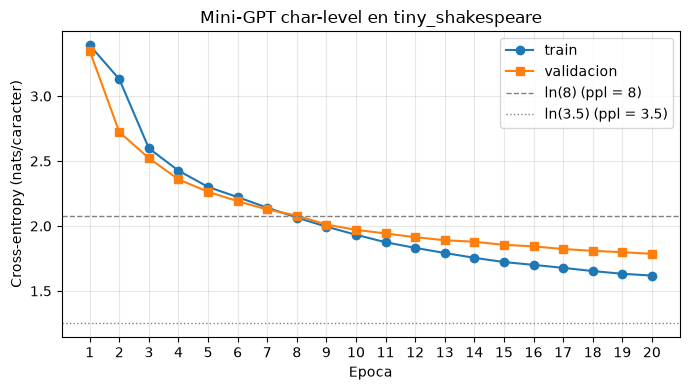

In [10]:
ep = range(1, len(history['train']) + 1)
plt.figure(figsize=(7, 4))
plt.plot(ep, history['train'], 'o-', label='train')
plt.plot(ep, history['val'], 's-', label='validacion')
plt.axhline(math.log(8.0), ls='--', c='gray', lw=1, label='ln(8) (ppl = 8)')
plt.axhline(math.log(3.5), ls=':',  c='gray', lw=1, label='ln(3.5) (ppl = 3.5)')
plt.xlabel('Epoca'); plt.ylabel('Cross-entropy (nats/caracter)')
plt.title('Mini-GPT char-level en tiny_shakespeare')
plt.xticks(list(ep)); plt.grid(alpha=.3); plt.legend(); plt.tight_layout()
plt.savefig('lab8_loss_curve.png', dpi=110); plt.show()

In [11]:
val_ce, N_val = evaluate_full(model, val_data)
val_ppl = math.exp(val_ce)
print(f'N tokens evaluados : {N_val:,}')
print(f'CE media validacion: {val_ce:.4f} nats/caracter')
print(f'Perplejidad val    : {val_ppl:.3f}')
print('Dentro del rango [3.5, 8.0]:', 3.5 <= val_ppl <= 8.0)

N tokens evaluados : 111,488
CE media validacion: 1.7859 nats/caracter
Perplejidad val    : 5.965
Dentro del rango [3.5, 8.0]: True


## Task 1.3

Las tres funciones reciben los **logits crudos** $z\in\mathbb{R}^{V}$ de la última posición y devuelven el índice del siguiente token. El softmax con temperatura y el muestreo de una distribución categórica también se implementan a mano:

- **Softmax con temperatura:** $P(w_i\mid\text{ctx})=\dfrac{\exp(z_i/\tau)}{\sum_j\exp(z_j/\tau)}$. Antes de exponenciar se resta $\max_j z_j/\tau$ para evitar overflow; el resultado no cambia.
- **Muestreo categórico (CDF inversa):** se toma $u\sim U(0,1)$ y se devuelve el primer $i$ tal que $\sum_{j\le i}P_j \ge u$.

In [12]:
def softmax_temperature(logits, tau=1.0):
    '''P(w_i | ctx) = exp(z_i / tau) / sum_j exp(z_j / tau)   (los -inf dan probabilidad 0)'''
    z = logits / tau
    z = z - z.max()              # estabilidad numerica: softmax es invariante a restar una constante
    e = torch.exp(z)
    return e / e.sum()

def sample_categorical(probs, generator=None):
    '''Muestreo por CDF inversa: primer i con F(i) = sum_{j<=i} p_j > u,  u ~ U(0,1)
    (desigualdad estricta: un token con p_i = 0 no hace crecer F, asi que nunca se elige)'''
    cdf = torch.cumsum(probs, dim=0)
    u = torch.rand(1, generator=generator, device=probs.device) * cdf[-1]   # *cdf[-1] por redondeo
    return int(torch.searchsorted(cdf, u, right=True).clamp(max=len(probs) - 1).item())


def greedy_sample(logits):
    '''Greedy: w* = argmax_i z_i (determinista; el argmax es igual para logits y para softmax)'''
    return int(torch.argmax(logits).item())

def top_k_sample(logits, k, tau=1.0, generator=None):
    '''
    Top-k con temperatura:
      1. z' = z / tau
      2. conservar los k mayores; z'_i = -inf para el resto
      3. P = softmax(z')  -> solo los k candidatos tienen masa
      4. muestrear de P
    '''
    z = logits / tau
    k = min(k, z.numel())
    top_idx = torch.sort(z, descending=True).indices[:k]       # indices de los k mayores
    z_masked = torch.full_like(z, float('-inf'))
    z_masked[top_idx] = z[top_idx]                              # el resto queda en -inf
    probs = softmax_temperature(z_masked, tau=1.0)              # ya se dividio por tau
    return sample_categorical(probs, generator)

def top_p_sample(logits, p, tau=1.0, generator=None, return_info=False):
    '''
    Top-p (nucleus) con temperatura:
      1. P = softmax(z / tau)
      2. ordenar P de mayor a menor
      3. incluir tokens hasta que la probabilidad acumulada supere p
         (se incluye el token que cruza el umbral, asi el nucleo nunca queda vacio)
      4. renormalizar dentro del nucleo y muestrear
    '''
    probs = softmax_temperature(logits, tau)
    sorted_p, sorted_idx = torch.sort(probs, descending=True)
    cum = torch.cumsum(sorted_p, dim=0)
    keep = (cum - sorted_p) < p          # masa acumulada ANTES del token < p  => el token entra
    nucleus_p = sorted_p * keep
    nucleus_p = nucleus_p / nucleus_p.sum()                     # renormalizar
    j = sample_categorical(nucleus_p, generator)
    idx = int(sorted_idx[j].item())
    if return_info:
        return idx, {'nucleus_size': int(keep.sum().item()), 'p_max': float(sorted_p[0].item())}
    return idx

In [13]:
# Pruebas unitarias sobre logits de juguete
z = torch.tensor([2.0, 1.0, 0.5, 0.1, -1.0])
g = torch.Generator().manual_seed(0)

assert greedy_sample(z) == 0
# top-k con k=2 nunca debe producir indices fuera de {0,1}
assert set(top_k_sample(z, k=2, tau=1.0, generator=g) for _ in range(500)) <= {0, 1}
# top-k con k=1 equivale a greedy
assert all(top_k_sample(z, k=1, generator=g) == 0 for _ in range(50))

P = softmax_temperature(z, 1.0)
print('softmax(z)      =', P.numpy().round(3), '| coincide con F.softmax:', torch.allclose(P, F.softmax(z, -1)))
print('softmax(z/0.5)  =', softmax_temperature(z, 0.5).numpy().round(3), '(tau<1 concentra)')
print('softmax(z/2.0)  =', softmax_temperature(z, 2.0).numpy().round(3), '(tau>1 aplana)')
# top-p: con P = [.559,.205,.125,.084,.028] (acumulada .559,.764,.889,.973,1):
#   p=0.5 -> {0}; p=0.7 -> {0,1}; p=0.95 -> {0,1,2,3}  (se incluye el token que cruza p)
for pp in [0.5, 0.7, 0.95]:
    _, info = top_p_sample(z, pp, return_info=True)
    print(f'top-p p={pp}: tamano del nucleo = {info["nucleus_size"]}')

# Frecuencias empiricas vs teoricas (top-k k=3, tau=1)
cnt = Counter(top_k_sample(z, 3, 1.0, g) for _ in range(20000))
teo = F.softmax(z[:3], -1)
print('top-k=3 empirico:', [round(cnt[i] / 20000, 3) for i in range(3)], '| teorico:', teo.numpy().round(3))

softmax(z)      = [0.559 0.205 0.125 0.084 0.028] | coincide con F.softmax: True
softmax(z/0.5)  = [0.826 0.112 0.041 0.018 0.002] (tau<1 concentra)
softmax(z/2.0)  = [0.372 0.226 0.176 0.144 0.083] (tau>1 aplana)
top-p p=0.5: tamano del nucleo = 1
top-p p=0.7: tamano del nucleo = 2
top-p p=0.95: tamano del nucleo = 4


top-k=3 empirico: [0.627, 0.23, 0.142] | teorico: [0.629 0.231 0.14 ]
